## **Descriptive Statistics**

**Goal**  
 Dive into daily and annualized returns, test statistical assumptions, and relationships between stocks to understand return behaviors.

**Stocks**  
AAPL,MSFT, NVDA, META, GOOGL, SPY

**Key questions**  
- What is the return and volatility of stocks?
- How correlated are these stocks, and does correlation change over time?
- Are the returns of high-performing stocks statistically significant?

In [1]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import yfinance as yf

# Load data, the same as Notebook 1
TICKERS = ['AAPL', 'MSFT', 'NVDA', 'META', 'GOOGL', 'SPY']
START   = '2020-01-01'
END     = '2025-12-31'

prices = pd.read_csv('data/prices_clean.csv', index_col=0, parse_dates=True)
returns = prices.pct_change().dropna()

print(f"Shape: {returns.shape}")
print(f"Date range: {returns.index[0].date()} → {returns.index[-1].date()}")

Shape: (1506, 6)
Date range: 2020-01-03 → 2025-12-30


### **Part 1 - Summary Statistics**
- Mean Daily Return
- Daily Volatility
- Annualized Return
- Annualized Volatility
- Sharpe Ratio

**Daily Return = (Today's Close - Yesterday's Close) / Yesterday's Close**

In [12]:
returns = prices.pct_change().dropna()
# check
print("Mean daily return rate:")
print(returns.mean().round(4))

Mean daily return rate:
Ticker
AAPL     0.0011
GOOGL    0.0012
META     0.0012
MSFT     0.0009
NVDA     0.0028
SPY      0.0006
dtype: float64


**Daily Volatility = standard deviation of daily return**

In [13]:
vol = returns.std()
print("Daily volatility:")
print(vol.round(4))

Daily volatility:
Ticker
AAPL     0.0200
GOOGL    0.0205
META     0.0276
MSFT     0.0186
NVDA     0.0335
SPY      0.0131
dtype: float64


In [14]:
annual_return = (1 + returns).prod() ** (252 / len(returns)) - 1
annual_volatility = returns.std() * np.sqrt(252)
# risk-free rate 4.5% is approximate 2024-2025 US T-bill rate
RISK_FREE_RATE = 0.045
sharpe_ratio = (annual_return - RISK_FREE_RATE) / annual_volatility

summary = pd.DataFrame({
    'Annual Return Rate': annual_return,
    'Annual Volatility': annual_volatility,
    'Sharpe Ratio': sharpe_ratio
}).round(4)

summary

,Annual Return Rate,Annual Volatility,Sharpe Ratio
Ticker,,,
AAPL,0.2486,0.3182,0.6397
GOOGL,0.2919,0.3248,0.7601
META,0.2147,0.4384,0.3870
MSFT,0.2146,0.2955,0.5740
NVDA,0.7803,0.5320,1.3822
SPY,0.1502,0.2075,0.5069


**Visualization**

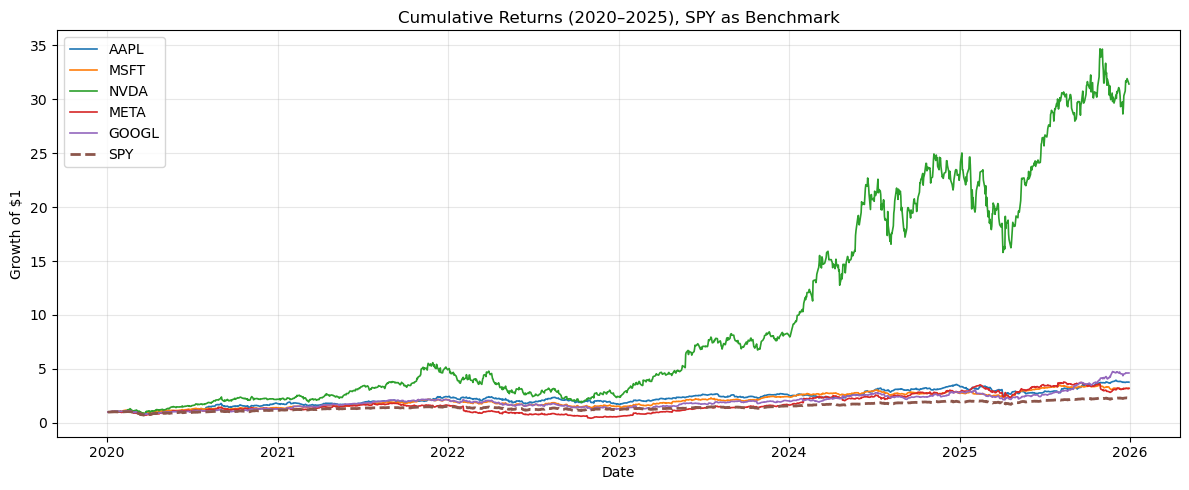

In [15]:
cumulative = (1 + returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))

for ticker in TICKERS:
    lw = 2.0 if ticker == 'SPY' else 1.2
    ls = '--' if ticker == 'SPY' else '-'
    ax.plot(cumulative[ticker], label=ticker, linewidth=lw, linestyle=ls)

ax.set_title('Cumulative Returns (2020–2025), SPY as Benchmark')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/cumulative_returns.png', dpi=150)
plt.show()

### **Part 2 - Correlation Analysis**
- Covariance and Correlation Matrices
- Correlation Heatmap
- Rolling Correlation

In [16]:
cov_matrix = returns.cov() * 252
corr_matrix = returns.corr()

print('Annulized Covariance Matrix:')
print(cov_matrix.round(4))
print('\nCorretation Matrix: ')
print(corr_matrix.round(4))

Annulized Covariance Matrix:
Ticker    AAPL   GOOGL    META    MSFT    NVDA     SPY
Ticker                                                
AAPL    0.1012  0.0644  0.0768  0.0667  0.0979  0.0518
GOOGL   0.0644  0.1055  0.0870  0.0672  0.0996  0.0489
META    0.0768  0.0870  0.1922  0.0808  0.1249  0.0576
MSFT    0.0667  0.0672  0.0808  0.0873  0.1062  0.0493
NVDA    0.0979  0.0996  0.1249  0.1062  0.2830  0.0775
SPY     0.0518  0.0489  0.0576  0.0493  0.0775  0.0431

Corretation Matrix: 
Ticker    AAPL   GOOGL    META    MSFT    NVDA     SPY
Ticker                                                
AAPL    1.0000  0.6231  0.5504  0.7091  0.5786  0.7839
GOOGL   0.6231  1.0000  0.6112  0.7001  0.5763  0.7254
META    0.5504  0.6112  1.0000  0.6235  0.5356  0.6328
MSFT    0.7091  0.7001  0.6235  1.0000  0.6757  0.8032
NVDA    0.5786  0.5763  0.5356  0.6757  1.0000  0.7016
SPY     0.7839  0.7254  0.6328  0.8032  0.7016  1.0000


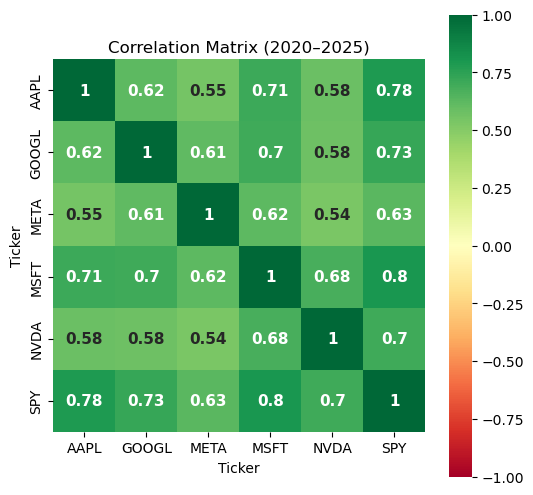

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sns.heatmap(corr_matrix,
           cmap='RdYlGn',
           vmin=-1, vmax=1,
           annot= True, square= True,
           annot_kws={'fontsize':11, 'fontweight':'bold'},)
ax.set_title('Correlation Matrix (2020–2025)')
plt.show()

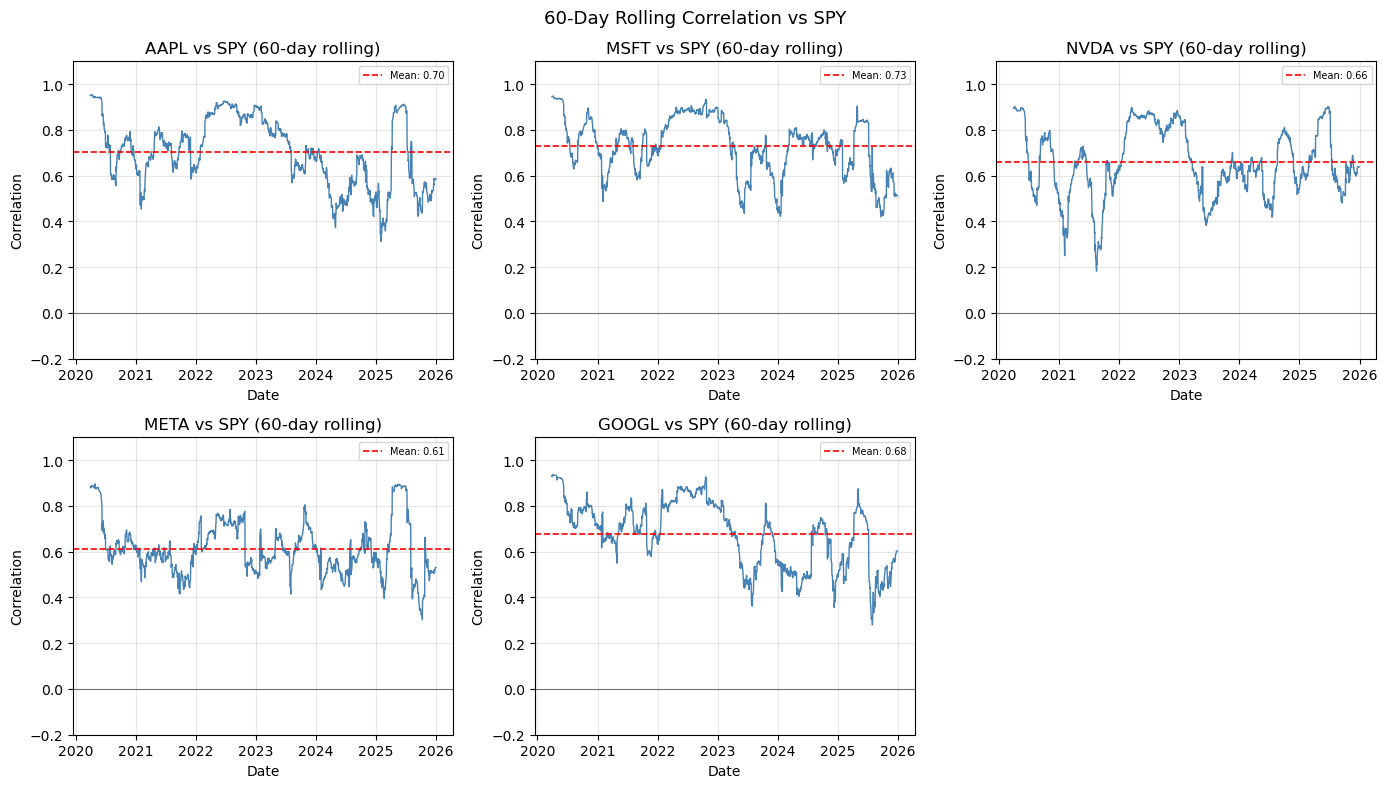

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate([t for t in TICKERS if t != 'SPY']):
    ax = axes[i]
    rolling_corr = returns[ticker].rolling(60).corr(returns['SPY'])
    
    ax.plot(rolling_corr, color='steelblue', linewidth=1.0)
    ax.axhline(rolling_corr.mean(), color='red', linestyle='--', 
               linewidth=1.2, label=f'Mean: {rolling_corr.mean():.2f}')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    
    ax.set_title(f'{ticker} vs SPY (60-day rolling)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Correlation')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.2, 1.1)

axes[-1].set_visible(False)  # hide empty 6th subplot

plt.suptitle('60-Day Rolling Correlation vs SPY', fontsize=13)
plt.tight_layout()
plt.savefig('charts/rolling_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### **Part 3 - Hypothesis Testing**

**1. One-Sample t-test: Is NVDA's mean return significantly greater than 0?**  

**Hypothesis:**
- H₀: μ = 0 (mean daily return is zero)
- H₁: μ > 0 (mean daily return is positive)
- One-tailed test, significance level α = 0.05

In [19]:
print("One-Sample t-test: \nH₀: mean daily return = 0")
# alignment
print(f"{'Ticker':<8} {'Mean':>8} {'t-stat':>10} {'p-value':>12} {'Reject H₀?':>12}")
print("-" * 55)
# testing
for ticker in TICKERS:
    data = returns[ticker].dropna()
    t_stat, p_two = stats.ttest_1samp(data, popmean=0)
    p_onetail = p_two / 2
    reject = "YES" if (p_onetail < 0.05 and t_stat > 0) else "NO"
    print(f"{ticker:<8} {data.mean():>8.4f} {t_stat:>10.4f} {p_onetail:>12.6f} {reject:>12}")

One-Sample t-test: 
H₀: mean daily return = 0
Ticker       Mean     t-stat      p-value   Reject H₀?
-------------------------------------------------------
AAPL       0.0011     2.0937     0.018227          YES
MSFT       0.0009     1.9698     0.024522          YES
NVDA       0.0028     3.2988     0.000497          YES
META       0.0012     1.6260     0.052083           NO
GOOGL      0.0012     2.3253     0.010094          YES
SPY        0.0006     1.9031     0.028608          YES


**2. Two-Sample t-test: Is NVDA's return significantly higher than SPY?**  

**Hypothesis:**
- H₀: μ_NVDA = μ_SPY (no difference in mean returns)
- H₁: μ_NVDA > μ_SPY
- One-tailed Welch's t-test (does not assume equal variance)

In [20]:
print("Two-Sample t-test: H₀: mean(stock) = mean(SPY)")
print(f"{'Ticker':<8} {'Δ Mean':>10} {'t-stat':>10} {'p-value':>12} {'Reject H₀?':>12}")
print("-" * 58)

spy_returns = returns['SPY'].dropna()

for ticker in [t for t in TICKERS if t != 'SPY']:
    data = returns[ticker].dropna()
    t_stat, p_two = stats.ttest_ind(data, spy_returns, equal_var=False)
    p_one = p_two / 2
    delta = data.mean() - spy_returns.mean()
    reject = "YES" if (p_one < 0.05 and t_stat > 0) else "NO"
    print(f"{ticker:<8} {delta:>10.4f} {t_stat:>10.4f} {p_one:>12.6f} {reject:>12}")

Two-Sample t-test: H₀: mean(stock) = mean(SPY)
Ticker       Δ Mean     t-stat      p-value   Reject H₀?
----------------------------------------------------------
AAPL         0.0004     0.7141     0.237629           NO
MSFT         0.0003     0.5185     0.302090           NO
NVDA         0.0022     2.3817     0.008664          YES
META         0.0005     0.6553     0.256182           NO
GOOGL        0.0006     0.9349     0.174970           NO


### **Key Observations**  
- **Highest annual return**: NVDA at 78% annualized - more than 5x SPY's 15% return.
- **Highest volatility**: NVDA at 53% - 2.6x the volatility of SPY (20%).
- **Best Sharpe**: NVDA at 1.38, driven by outsized returns compensating for high risk.
- **SPY benchmark**: Sharpe of 0.51 — most individual stocks failed to beat it on a risk-adjusted basis; only NVDA and GOOGL exceeded it
- **Lowest correlation with SPY**: META, therefore it is the best diversifier.
- **t-test result**: NVDA's mean return is statistically significantly greater than both 0 and SPY's mean (p < 0.05), but this is in-sample and does not imply future outperformance.